# P0 · Classes and instances

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.8 · Classes and instances

An instance keeps its own state. Its methods use self to access that state.

**Prerequisites:** Imports, files, and configuration

**Predict:** Two tokenizer instances can give one ID different meanings.

**Mental model:** A tokenizer needs both a vocabulary and operations that use it. A class describes how to build an object that keeps those pieces together.

### P0.8.1 · Understand the need

A tokenizer needs both a vocabulary and operations that use it. A class describes how to build an object that keeps those pieces together.

Constructing a tokenizer creates an instance. Constructing another tokenizer creates another instance with its own vocabulary.

The method parameter self refers to the instance receiving the call. It tells the method which stored mapping to consult.

The same integer IDs can decode differently in two tokenizer instances. The object state supplies the meaning that the bare IDs do not contain.

This is the same programming pattern used to organize neural network layers. First understand it with a small vocabulary you can inspect completely.

### P0.8.2 · Follow the values

Construct the first tokenizer from the letters a and b. Its sorted vocabulary gives the letter a ID zero and the letter b ID one.

Construct the second from x and y. It has its own vocabulary and its own mapping, with the same number of entries.

Ask the first object to encode b followed by a. It returns one followed by zero using the first mapping.

Ask the second object to decode those same IDs. It returns y followed by x, because the second vocabulary has different characters.

The two stored dictionaries are separate objects. Add c to the first construction in the experiment and inspect which object's state changes.

In [3]:
FRAMES.clear()
change = 0
class Tokenizer:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
    def encode(self, text):
        return [self.stoi[ch] for ch in text]
    def decode(self, ids):
        return "".join(self.chars[i] for i in ids)
first = Tokenizer("ab" if not change else "abc")
second = Tokenizer("xy")
show("First object's vocabulary", first.chars)
show("Second object's vocabulary", second.chars)
show("First object encodes ba", first.encode("ba"))
show("Second object decodes the same IDs", second.decode([1, 0]))
show("Separate instance state", first.stoi is not second.stoi)

First object's vocabulary: ["a", "b"]
Second object's vocabulary: ["x", "y"]
First object encodes ba: [1, 0]
Second object decodes the same IDs: "yx"
Separate instance state: true


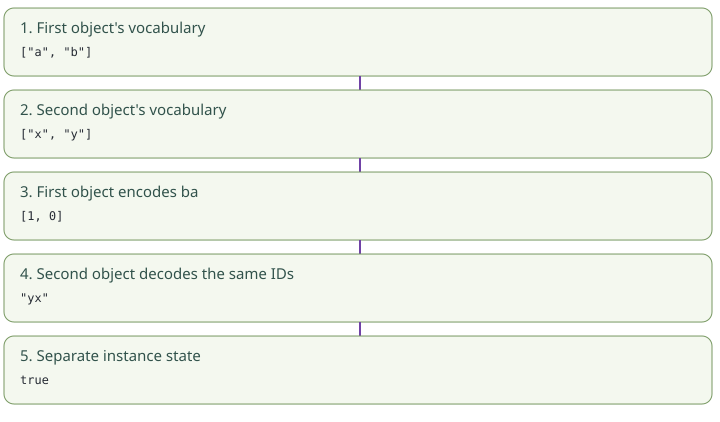

In [4]:
draw_trace()

### P0.8.3 · Read and run the code

The class statement defines the construction and behavior of Tokenizer. Calling the class creates an instance and invokes its initialization method.

Inside initialization, two attributes store the character list and the character-to-ID mapping. Both belong to this instance, reached through self.

The encode method receives the instance through self and the requested text through its explicit argument. Calling first dot encode supplies the instance automatically.

Decode reads the stored character list and joins its selected entries. The two methods share state through self rather than through unrelated global variables.

Keep per-instance mutable data inside initialization. A mutable class attribute would instead be shared across instances unless deliberately overridden.

### Change one thing

**Add c to the first vocabulary**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
class Tokenizer:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
    def encode(self, text):
        return [self.stoi[ch] for ch in text]
    def decode(self, ids):
        return "".join(self.chars[i] for i in ids)
first = Tokenizer("ab" if not change else "abc")
second = Tokenizer("xy")
show("First object's vocabulary", first.chars)
show("Second object's vocabulary", second.chars)
show("First object encodes ba", first.encode("ba"))
show("Second object decodes the same IDs", second.decode([1, 0]))
show("Separate instance state", first.stoi is not second.stoi)

First object's vocabulary: ["a", "b", "c"]
Second object's vocabulary: ["x", "y"]
First object encodes ba: [1, 0]
Second object decodes the same IDs: "yx"
Separate instance state: true


### A useful distinction

self is the receiving instance, not one global object shared by all instances.

### ✋ Your turn

Create a Tokenizer for "cab", encode "bac", and put the resulting list in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 0, 2], 'self is the receiving instance, not one global object shared by all instances.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
answer = Tokenizer("cab").encode("bac")

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 0, 2], 'self is the receiving instance, not one global object shared by all instances.'
    print("✓ right:", answer)

✓ right: [1, 0, 2]


### P0.8.4 · Find it in the model

The current tokenizer uses this exact object pattern. A saved model must be paired with the tokenizer state that was used to interpret its training data.

A neural network module also keeps state, including submodules and learned tensors. Its forward method uses that state to calculate an output.

A method call and an attribute lookup are different: parentheses execute a callable, while an attribute expression retrieves the stored value or method.

Composition means storing another object as an attribute. A transformer stores attention and feed-forward modules this way.

Next, extend this foundation to inheritance, configuration objects and the compact syntax in the actual model file.

```python
tokenizer = Tokenizer(text)
ids = tokenizer.encode(prompt)
reply = tokenizer.decode(generated_ids)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Two tokenizer instances can give one ID different meanings.

<details><summary>Check your explanation</summary>

True; their vocabularies can differ. self is the receiving instance, not one global object shared by all instances.

</details>